## 3.5 PennyLane으로 하는 양자 머신러닝

In [ ]:
%pip install -q pennylane

In [1]:
import pennylane as qml
from pennylane import numpy as np
from pennylane.optimize import NesterovMomentumOptimizer
import matplotlib.pyplot as plt

%matplotlib inline

In [2]:
# 디바이스 정의
# 호환성 수정: pennylane-qiskit 플러그인이 없으면 'qiskit.aer' 대신 PennyLane 내장 'default.qubit' 사용
dev = qml.device('default.qubit', wires=2)

In [3]:
# 변분 회로 정의
@qml.qnode(dev)
def circuit(weights, x=None):
    qml.AngleEmbedding(x, wires=range(2))
    qml.StronglyEntanglingLayers(weights, wires=range(2))
    return qml.expval(qml.PauliZ(0))

In [4]:
# 최적화할 비용함수
def cost(weights, x, y):
    predictions = np.array([circuit(weights, x=x_) for x_ in x])
    return np.mean((predictions - y) ** 2)

In [5]:
# 무작위 데이터 생성
np.random.seed(42)
X = np.random.rand(100, 2)
Y = np.array([1 if x[0] + x[1] > 1 else -1 for x in X])

In [6]:
# 가중치 초기화
weights = 0.01 * np.random.randn(3, 2, 3)

In [7]:
# 모델 학습
opt = NesterovMomentumOptimizer(0.5)
steps = 50

for i in range(steps):
    weights = opt.step(lambda w: cost(w, X, Y), weights)
    if i % 10 == 0:
        print(f'Step {i}: Cost = {cost(weights, X, Y)}')

print('Training complete')

Step 0: Cost = 2.170979439880976
Step 10: Cost = 0.6281058178064538
Step 20: Cost = 0.5894525190712966
Step 30: Cost = 0.5884274285935148
Step 40: Cost = 0.5875595157733503
Training complete


Matplotlib is building the font cache; this may take a moment.


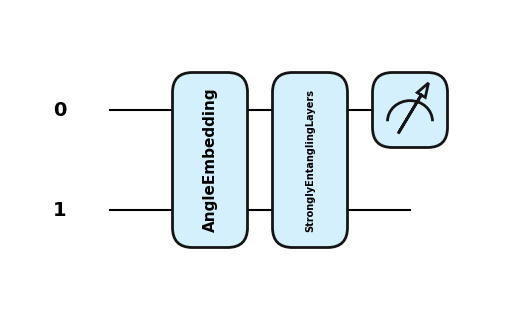

In [11]:
import matplotlib.pyplot as plt

# 학습된 최종 회로 시각화 (matplotlib)
fig, ax = qml.draw_mpl(circuit, style="pennylane")(weights, x=X[0])
plt.show()